# Day 07 — Multiscale
### #30DayChartChallenge | April 2026

**Not all carbon footprints are equal.** The richest countries emit 0.06 to 40 tonnes of CO2 per person — a 570x range. A raincloud plot showing the full distribution of CO2 emissions per capita across 191 countries, grouped by World Bank income level.

**Data:**  
Our World in Data / Global Carbon Project, 2023.  
Income groups: World Bank, 2024.  
Source: [github.com/owid/co2-data](https://github.com/owid/co2-data)

**Author:** Sharfudeen Yasar Arafath

In [38]:
# — packages ------------------------------------------------------------------
# install.packages("ggridges")  # run once if not installed

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(ggridges)

In [39]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 14, repr.plot.height = 10, repr.plot.res = 300)

In [40]:
# — read data -----------------------------------------------------------------

df <- read.csv("../../data/day_07/co2_per_capita_by_income_2023.csv",
               stringsAsFactors = FALSE)

# remove rows with missing income group
df <- df[!is.na(df$income_group) & df$income_group != "" & df$income_group != "Not classified", ]

df$income_group <- factor(df$income_group,
  levels = c("Low income", "Lower middle income",
             "Upper middle income", "High income")
)
df <- df[!is.na(df$income_group), ]

# continent as factor
df$continent <- factor(df$continent)

# highlight countries
highlights <- c("Qatar", "United States", "China", "India",
                "Germany", "Brazil", "Nigeria", "Burundi")
df$highlight <- ifelse(df$country %in% highlights, df$country, NA)

cat(nrow(df), "countries loaded\n")
table(df$income_group, useNA = "always")

191 countries loaded



         Low income Lower middle income Upper middle income         High income 
                 26                  49                  54                  62 
               <NA> 
                  0 

In [41]:
# — theme & palette -----------------------------------------------------------

bg      <- "#0D1117"
txt     <- "#E6EDF3"
txt_dim <- "#8B949E"
txt_cap <- "#484F58"

# income group colors for ridges
income_colors <- c(
  "Low income"           = "#2ECC71",
  "Lower middle income"  = "#3498DB",
  "Upper middle income"  = "#F39C12",
  "High income"          = "#E74C3C"
)

# continent colors for dots (5 clean groups)
continent_colors <- c(
  "Africa"       = "#1ABC9C",
  "Americas"     = "#9B59B6",
  "Asia"         = "#E67E22",
  "Europe"       = "#3498DB",
  "Middle East"  = "#E74C3C"
)

Picking joint bandwidth of 0.104



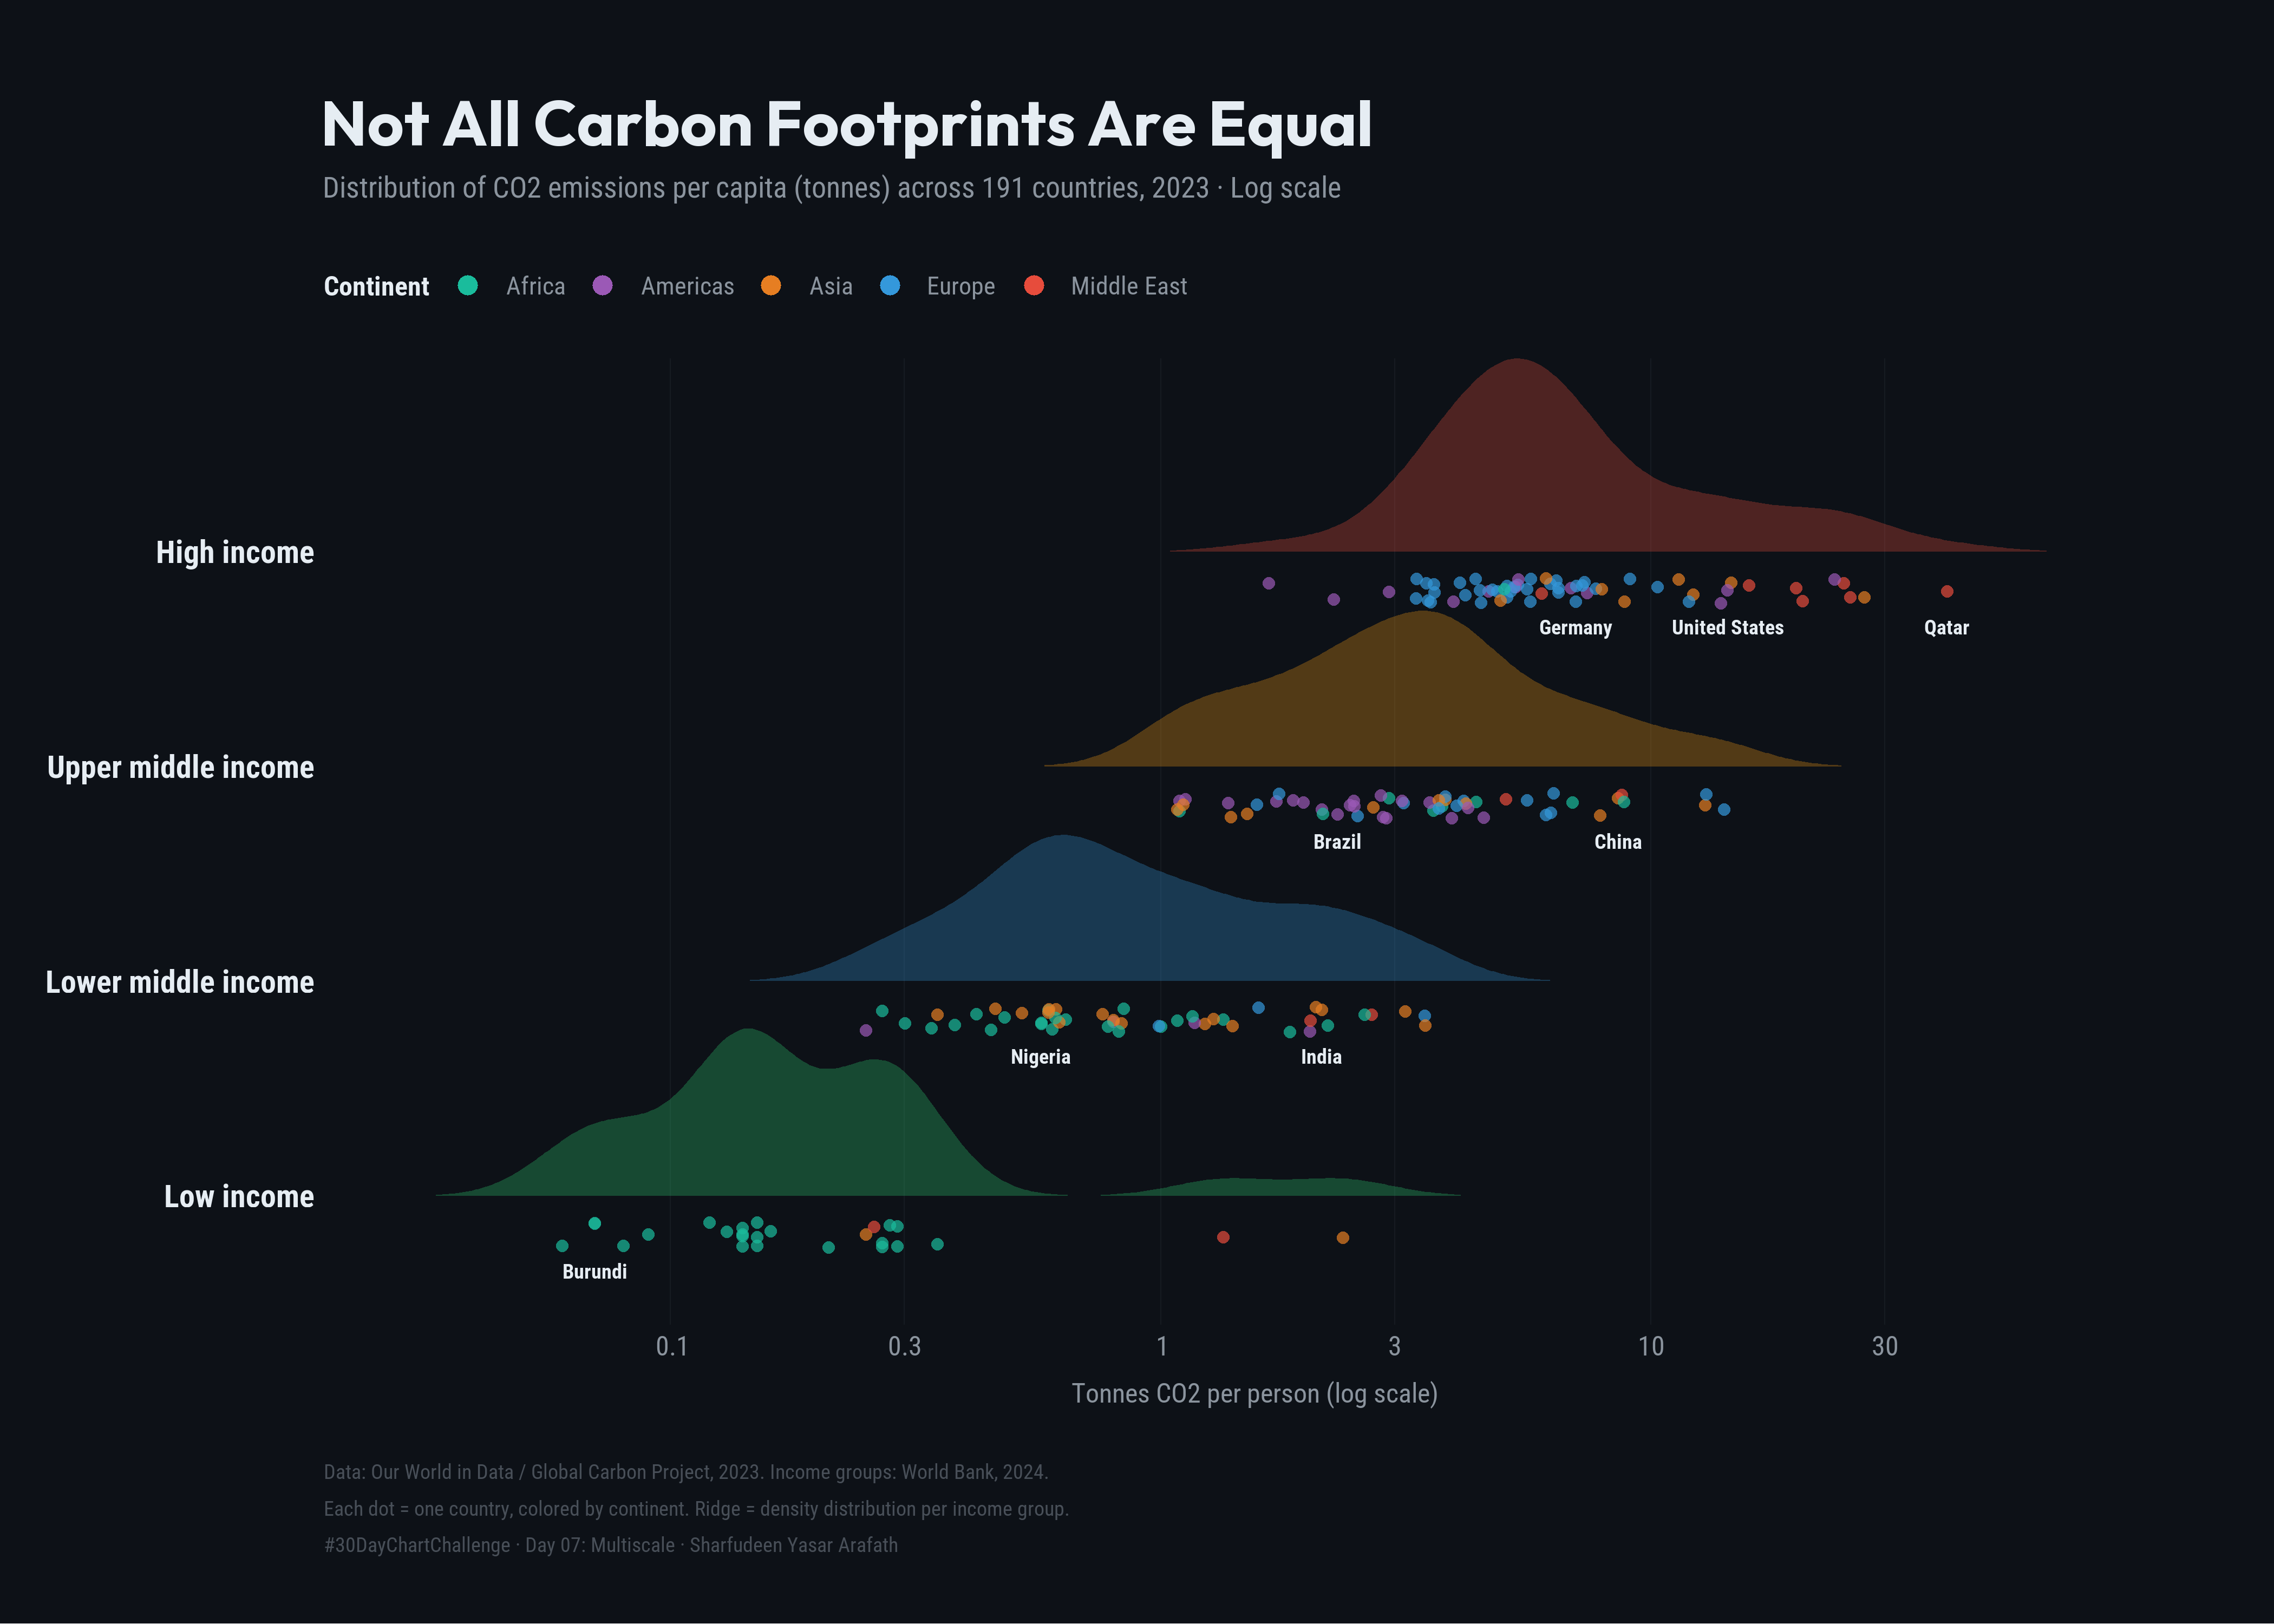

In [42]:
# — plot: ridgeline + continent-colored jitter --------------------------------

p <- ggplot(df, aes(x = co2_per_capita, y = income_group)) +

  # ridgeline density (filled by income group)
  geom_density_ridges(
    aes(fill = income_group),
    alpha = 0.3, scale = 0.9, rel_min_height = 0.005,
    color = NA
  ) +

  # jitter dots colored by continent
  geom_jitter(
    aes(y = as.numeric(income_group) - 0.18, color = continent),
    height = 0.06, size = 2.2, alpha = 0.7, shape = 16
  ) +

  # highlighted country labels
  geom_text(
    data = df %>% filter(!is.na(highlight)),
    aes(x = co2_per_capita, y = as.numeric(income_group) - 0.35,
        label = highlight),
    color = txt, family = "roboto_condensed", fontface = "bold",
    size = 3.2, hjust = 0.5, inherit.aes = FALSE
  ) +

  scale_x_log10(
    breaks = c(0.1, 0.3, 1, 3, 10, 30),
    labels = c("0.1", "0.3", "1", "3", "10", "30")
  ) +
  scale_fill_manual(values = income_colors, guide = "none") +
  scale_color_manual(values = continent_colors, name = "Continent") +

  labs(
    title    = "Not All Carbon Footprints Are Equal",
    subtitle = paste0(
      "Distribution of CO2 emissions per capita (tonnes) across ",
      nrow(df), " countries, 2023 ",
      "\u00b7 Log scale"
    ),
    x        = "Tonnes CO2 per person (log scale)",
    y        = NULL,
    caption  = paste0(
      "Data: Our World in Data / Global Carbon Project, 2023. ",
      "Income groups: World Bank, 2024.\n",
      "Each dot = one country, colored by continent. ",
      "Ridge = density distribution per income group.\n",
      "#30DayChartChallenge \u00b7 Day 07: Multiscale \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title       = element_text(family = "outfit", face = "bold", size = 28,
                                    hjust = 0, color = txt,
                                    margin = margin(t = 20, b = 8)),
    plot.subtitle    = element_text(size = 13, hjust = 0, color = txt_dim,
                                    margin = margin(b = 25)),
    plot.caption     = element_text(size = 9, hjust = 0, color = txt_cap,
                                    margin = margin(t = 25, b = 10),
                                    lineheight = 1.5),
    axis.text.y      = element_text(size = 14, color = txt, face = "bold",
                                    margin = margin(r = 5)),
    axis.text.x      = element_text(size = 12, color = txt_dim),
    axis.title.x     = element_text(size = 12, color = txt_dim,
                                    margin = margin(t = 10)),
    panel.grid.major.x = element_line(color = "#161B22", linewidth = 0.3),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_blank(),
    legend.position  = "top",
    legend.justification = "left",
    legend.text      = element_text(size = 11, color = txt_dim),
    legend.title     = element_text(size = 12, color = txt, face = "bold"),
    legend.key.size  = unit(0.8, "cm"),
    legend.margin    = margin(b = 10),
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin      = margin(25, 40, 20, 20)
  ) +
  guides(color = guide_legend(
    nrow = 1, override.aes = list(size = 4, alpha = 1)
  ))

p

In [43]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_07_multiscale.png",
       plot = p, width = 14, height = 10, dpi = 300, bg = bg)

cat("Done — saved to chart/day_07_multiscale.png\n")

Picking joint bandwidth of 0.104



Done — saved to chart/day_07_multiscale.png
